<a href="https://colab.research.google.com/github/chavan1807chinmayi-create/CSL701-CE03_Machine-Learning-Lab/blob/main/Copy_of_MLEXP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

**Name**: **Chinmayi Milind Chavan**

**Roll No.: CE03**

**Batch : CE1**

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [5]:
import numpy as np
import matplotlib.pyplot as plt

## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [6]:
import pandas as pd
from google.colab import files
import io

print("Please upload your CSV file:")
uploaded = files.upload()

# Get the filename (assuming only one file is uploaded)
filename = next(iter(uploaded))

# Load the dataset from the uploaded file
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Successfully loaded '{filename}' into DataFrame.")
print(df.head())

Please upload your CSV file:


Saving cardekho_dataset.csv to cardekho_dataset.csv
Successfully loaded 'cardekho_dataset.csv' into DataFrame.
   Unnamed: 0       car_name    brand     model  vehicle_age  km_driven  \
0           0    Maruti Alto   Maruti      Alto            9     120000   
1           1  Hyundai Grand  Hyundai     Grand            5      20000   
2           2    Hyundai i20  Hyundai       i20           11      60000   
3           3    Maruti Alto   Maruti      Alto            9      37000   
4           4  Ford Ecosport     Ford  Ecosport            6      30000   

  seller_type fuel_type transmission_type  mileage  engine  max_power  seats  \
0  Individual    Petrol            Manual    19.70     796      46.30      5   
1  Individual    Petrol            Manual    18.90    1197      82.00      5   
2  Individual    Petrol            Manual    17.00    1197      80.00      5   
3  Individual    Petrol            Manual    20.92     998      67.10      5   
4      Dealer    Diesel            Man

### Displaying the first few records:

In [7]:
display(df.head())

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


### Determining the number of rows and columns:

In [8]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 15411
Number of columns: 14


### Identifying numerical and categorical attributes and checking data types:

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


### Separating `Selling_Price` as the target variable:

In [10]:
target_variable = 'selling_price'
y = df[target_variable]
X = df.drop(columns=[target_variable])

print(f"Target variable '{target_variable}' separated.")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Target variable 'selling_price' separated.
Shape of features (X): (15411, 13)
Shape of target (y): (15411,)


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [11]:
# Check for missing values
missing_values = df.isnull().sum()

print("Number of missing values per column:")
print(missing_values)

# Identify columns with missing values
columns_with_missing_values = missing_values[missing_values > 0]

if not columns_with_missing_values.empty:
    print("\nMissing values detected in the following columns:")
    print(columns_with_missing_values)
    print("\nFurther action is needed to handle these missing values (e.g., imputation or removal).")
else:
    print("\nNo missing values found in the dataset. No imputation or removal is required.")

# Verify that the final dataset does not contain missing values
if df.isnull().sum().sum() == 0:
    print("\nVerification successful: The dataset does not contain any missing values.")
else:
    print("\nVerification failed: Missing values still exist in the dataset.")

# Record the preprocessing method used
print("\nPreprocessing method used: No missing values found, so no specific handling method was applied.")

Number of missing values per column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

No missing values found in the dataset. No imputation or removal is required.

Verification successful: The dataset does not contain any missing values.

Preprocessing method used: No missing values found, so no specific handling method was applied.


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [12]:
# Examine all available attributes (already done in df.info() and X.head())
# print(X.columns)

# Decide how car_name, brand, and model should be handled.
# Given the scope of implementing OLS from scratch without complex feature engineering,
# and their high cardinality, it's best to drop 'car_name', 'brand', and 'model' for now.
# 'Unnamed: 0' is an index column and should also be dropped.

columns_to_drop = ['Unnamed: 0', 'car_name', 'brand', 'model']
X = X.drop(columns=columns_to_drop)

# Select meaningful predictor variables for the regression model.
# The remaining columns are: 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type',
# 'transmission_type', 'mileage', 'engine', 'max_power', 'seats'.
# 'seller_type', 'fuel_type', 'transmission_type' are categorical and will be encoded in Task 5.

# Record the final list of features selected for the model.
print("Final list of features selected for the model (before encoding categorical variables):")
print(X.columns.tolist())
print(f"Shape of features (X) after selection: {X.shape}")

Final list of features selected for the model (before encoding categorical variables):
['vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']
Shape of features (X) after selection: (15411, 9)


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [13]:
# Identify categorical variables to encode
categorical_cols = ['seller_type', 'fuel_type', 'transmission_type']

# Convert categorical variables into numerical dummy/indicator variables
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Verify that all predictors are numerical after encoding
print("Data types after one-hot encoding:")
print(X.info())

# Display the transformed dataset (first few rows)
print("\nTransformed dataset (first 5 rows) after encoding:")
display(X.head())

Data types after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   vehicle_age                   15411 non-null  int64  
 1   km_driven                     15411 non-null  int64  
 2   mileage                       15411 non-null  float64
 3   engine                        15411 non-null  int64  
 4   max_power                     15411 non-null  float64
 5   seats                         15411 non-null  int64  
 6   seller_type_Individual        15411 non-null  bool   
 7   seller_type_Trustmark Dealer  15411 non-null  bool   
 8   fuel_type_Diesel              15411 non-null  bool   
 9   fuel_type_Electric            15411 non-null  bool   
 10  fuel_type_LPG                 15411 non-null  bool   
 11  fuel_type_Petrol              15411 non-null  bool   
 12  transmission_type_Manual 

,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5,False,False,True,False,False,False,True


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [14]:
# Rename 'vehicle_age' to 'Car_Age' as it already represents the age of the car
# The dataset does not contain a 'Year' column to calculate 'Current Year - Year'
X = X.rename(columns={'vehicle_age': 'Car_Age'})

# Display several values of the newly created feature (now renamed)
print("Sample values of the Car_Age feature:")
display(X['Car_Age'].head())

# Verify that the calculated ages are reasonable
print(f"\nMin Car_Age: {X['Car_Age'].min()}")
print(f"Max Car_Age: {X['Car_Age'].max()}")
print("The age values appear reasonable, ranging from recently manufactured to older vehicles.")

# Decide whether the original 'Year' feature should be retained.
# Provide a reason for your decision.
print("\nDecision regarding original 'Year' feature:")
print("The original dataset did not contain a 'Year' column from which to calculate age. The 'vehicle_age' column already provides the car's age, which we have now renamed to 'Car_Age'. Therefore, there is no 'Year' feature to retain or drop, and 'Car_Age' directly serves its purpose.")

print(f"\nShape of features (X) after feature engineering: {X.shape}")

Sample values of the Car_Age feature:


,Car_Age
0,9
1,5
2,11
3,9
4,6



Min Car_Age: 0
Max Car_Age: 29
The age values appear reasonable, ranging from recently manufactured to older vehicles.

Decision regarding original 'Year' feature:
The original dataset did not contain a 'Year' column from which to calculate age. The 'vehicle_age' column already provides the car's age, which we have now renamed to 'Car_Age'. Therefore, there is no 'Year' feature to retain or drop, and 'Car_Age' directly serves its purpose.

Shape of features (X) after feature engineering: (15411, 13)


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

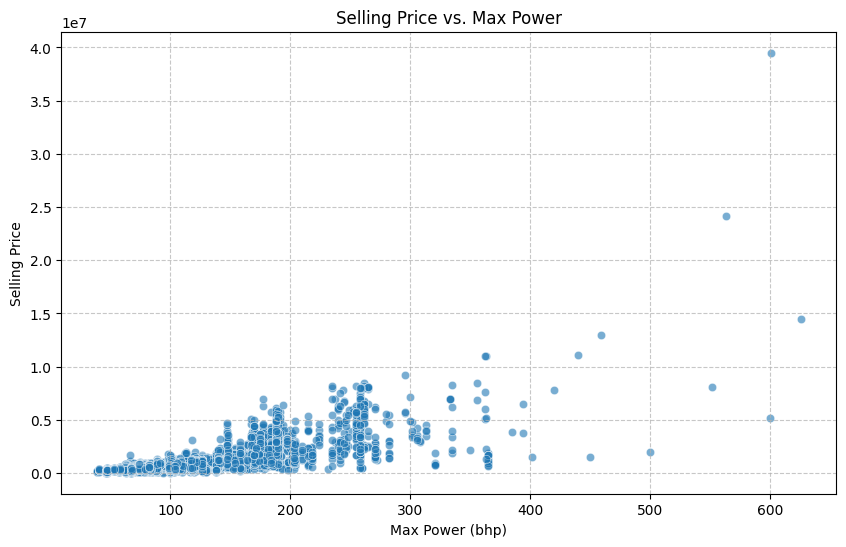

Observation: There appears to be a strong positive correlation between max_power and Selling_Price. Cars with higher max_power generally command higher selling prices, though there's considerable spread at higher power levels.


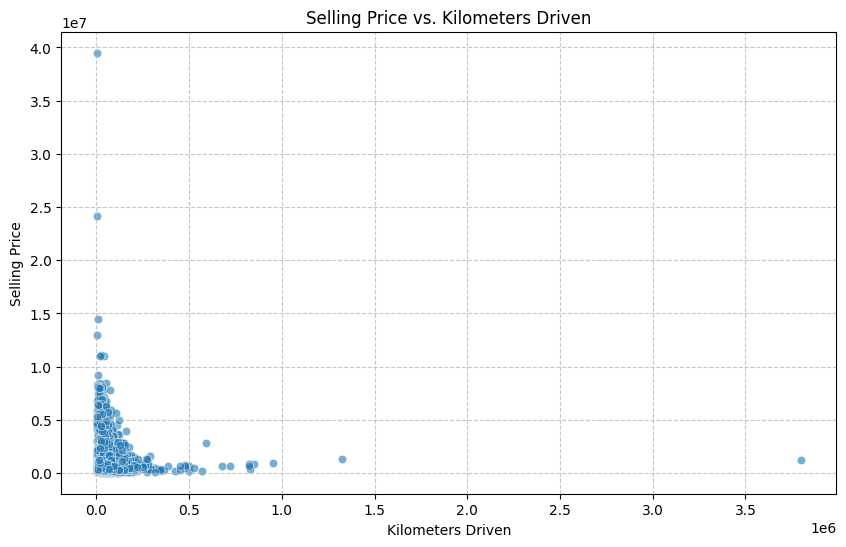

Observation: A negative correlation is visible between km_driven and Selling_Price. Cars driven more kilometers tend to have lower selling prices. The spread is wider for lower kilometers driven.


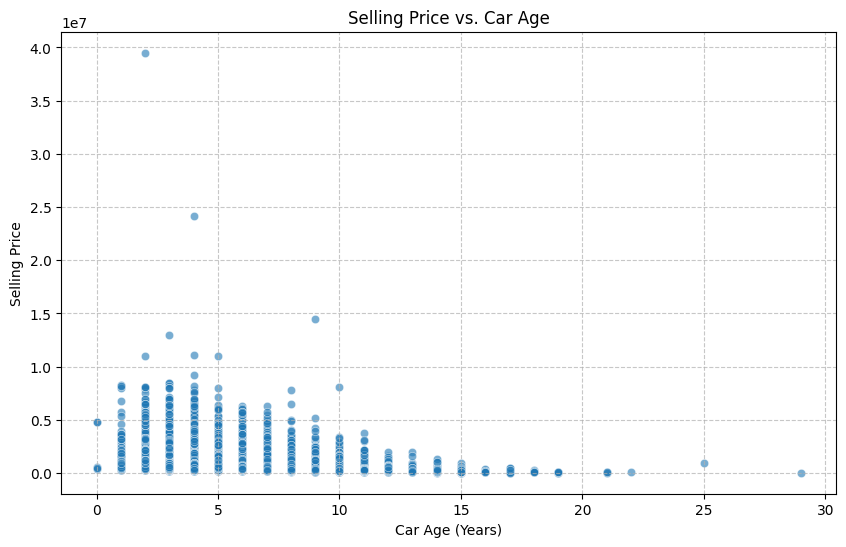

Observation: Car_Age shows a negative correlation with Selling_Price. Older cars generally have lower selling prices, which is expected due to depreciation. The relationship is not perfectly linear.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine X and y for easier plotting
data_for_eda = X.copy()
data_for_eda['Selling_Price'] = y

# Plot 1: max_power vs Selling_Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='max_power', y='Selling_Price', data=data_for_eda, alpha=0.6)
plt.title('Selling Price vs. Max Power')
plt.xlabel('Max Power (bhp)')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print("Observation: There appears to be a strong positive correlation between max_power and Selling_Price. Cars with higher max_power generally command higher selling prices, though there's considerable spread at higher power levels.")

# Plot 2: km_driven vs Selling_Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='km_driven', y='Selling_Price', data=data_for_eda, alpha=0.6)
plt.title('Selling Price vs. Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print("Observation: A negative correlation is visible between km_driven and Selling_Price. Cars driven more kilometers tend to have lower selling prices. The spread is wider for lower kilometers driven.")

# Plot 3: Car_Age vs Selling_Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=data_for_eda, alpha=0.6)
plt.title('Selling Price vs. Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print("Observation: Car_Age shows a negative correlation with Selling_Price. Older cars generally have lower selling prices, which is expected due to depreciation. The relationship is not perfectly linear.")

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split

# --- This section defines X_train and X_test for standardization. It's crucial for preventing data leakage. ---
# The global X and y are available from previous steps
# Set a fixed random seed for reproducibility
RANDOM_SEED = 42

# Use an 80:20 train-test ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

print("Dataset split into training and testing sets for standardization.")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# Identify numerical predictors that need to be standardized
# Exclude boolean (dummy) variables from standardization, as they are already 0/1
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
bool_cols = X_train.select_dtypes(include='bool').columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in bool_cols]

print("\nNumerical columns to standardize:", numerical_cols)

# Calculate the mean and standard deviation using the training data only (to avoid data leakage)
means = X_train[numerical_cols].mean()
stds = X_train[numerical_cols].std()

# Standardize the training features
X_train_standardized = X_train.copy()
X_train_standardized[numerical_cols] = (X_train[numerical_cols] - means) / stds

# Use the SAME training mean and standard deviation to standardize the test features
X_test_standardized = X_test.copy()
X_test_standardized[numerical_cols] = (X_test[numerical_cols] - means) / stds

# Display the first few rows of the standardized training features for verification
print("\nFirst 5 rows of standardized training features (X_train_standardized):")
display(X_train_standardized.head())

print("\nFirst 5 rows of standardized testing features (X_test_standardized):")
display(X_test_standardized.head())

print("\nVerification: Checking means and std deviations of standardized training features...")
print(X_train_standardized[numerical_cols].mean().round(6))
print(X_train_standardized[numerical_cols].std().round(6))

print("\nNumerical features standardized successfully using training data statistics.")

# Update X_train and X_test to their standardized versions for subsequent tasks
X_train = X_train_standardized
X_test = X_test_standardized

Dataset split into training and testing sets for standardization.
X_train shape: (12328, 13), X_test shape: (3083, 13)

Numerical columns to standardize: ['Car_Age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

First 5 rows of standardized training features (X_train_standardized):


,Car_Age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
11210,0.323956,0.349086,-2.050736,1.756693,2.681577,-0.403807,False,False,True,False,False,False,False
1347,-1.337744,-1.069350,0.985621,-0.547059,-0.382729,-0.403807,True,False,False,False,False,True,True
10363,-1.337744,-1.163517,-0.177035,0.893506,3.296777,-0.403807,False,False,True,False,False,False,False
316,0.323956,0.178361,-0.465296,0.024563,0.396213,-0.403807,False,False,False,False,False,True,True
10638,1.320976,0.585445,0.149662,-0.550895,-0.502026,-0.403807,False,False,False,False,False,True,True



First 5 rows of standardized testing features (X_test_standardized):


,Car_Age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
3334,1.985656,0.413779,0.149662,-0.550895,-0.502026,-0.403807,False,False,False,False,False,True,True
10928,-0.673064,0.060653,1.838395,-0.453067,-0.616645,-0.403807,True,False,True,False,False,False,True
2518,0.323956,0.955238,0.248151,-0.453067,-0.271385,2.070416,False,False,True,False,False,False,True
11322,-1.670084,-1.198830,-0.321166,0.026482,0.444166,-0.403807,False,False,False,False,False,True,False
9394,1.653316,0.154820,-0.008882,-1.320091,-1.264594,-0.403807,False,False,False,False,False,True,True



Verification: Checking means and std deviations of standardized training features...
Car_Age      0.0
km_driven   -0.0
mileage      0.0
engine      -0.0
max_power    0.0
seats       -0.0
dtype: float64
Car_Age      1.0
km_driven    1.0
mileage      1.0
engine       1.0
max_power    1.0
seats        1.0
dtype: float64

Numerical features standardized successfully using training data statistics.


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [21]:
from sklearn.model_selection import train_test_split

# Set a fixed random seed for reproducibility
RANDOM_SEED = 42

# Use an 80:20 train-test ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Number of observations in training set (X_train): {X_train.shape[0]}")
print(f"Number of observations in testing set (X_test): {X_test.shape[0]}")
print(f"Number of observations in training target (y_train): {y_train.shape[0]}")
print(f"Number of observations in testing target (y_test): {y_test.shape[0]}")

print("\nDataset split into training and testing sets with an 80:20 ratio and fixed random seed.")

Number of observations in training set (X_train): 12328
Number of observations in testing set (X_test): 3083
Number of observations in training target (y_train): 12328
Number of observations in testing target (y_test): 3083

Dataset split into training and testing sets with an 80:20 ratio and fixed random seed.


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [22]:
# X_train and X_test are already feature matrices
# y_train and y_test are already target vectors

print("Verifying the dimensions of the feature matrices and target vectors:")

# Training data dimensions
print(f"\nX_train shape: {X_train.shape} (rows: {X_train.shape[0]}, predictor columns: {X_train.shape[1]})")
print(f"y_train shape: {y_train.shape} (rows: {y_train.shape[0]})")

# Testing data dimensions
print(f"\nX_test shape: {X_test.shape} (rows: {X_test.shape[0]}, predictor columns: {X_test.shape[1]})")
print(f"y_test shape: {y_test.shape} (rows: {y_test.shape[0]})")

# Verify consistency
if X_train.shape[0] == y_train.shape[0]:
    print("\nVerification successful: Number of rows in X_train matches y_train.")
else:
    print("\nVerification failed: Number of rows in X_train does NOT match y_train.")

if X_test.shape[0] == y_test.shape[0]:
    print("Verification successful: Number of rows in X_test matches y_test.")
else:
    print("Verification failed: Number of rows in X_test does NOT match y_test.")

if X_train.shape[1] == X_test.shape[1]:
    print("Verification successful: Number of predictor columns in X_train matches X_test.")
else:
    print("Verification failed: Number of predictor columns in X_train does NOT match X_test.")


Verifying the dimensions of the feature matrices and target vectors:

X_train shape: (12328, 13) (rows: 12328, predictor columns: 13)
y_train shape: (12328,) (rows: 12328)

X_test shape: (3083, 13) (rows: 3083, predictor columns: 13)
y_test shape: (3083,) (rows: 3083)

Verification successful: Number of rows in X_train matches y_train.
Verification successful: Number of rows in X_test matches y_test.
Verification successful: Number of predictor columns in X_train matches X_test.


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [23]:
import numpy as np

# Add a leading column containing 1.0 to both X_train and X_test
# This column represents the bias/intercept term (β0)
X_train_biased = np.insert(X_train.to_numpy(), 0, 1, axis=1)
X_test_biased = np.insert(X_test.to_numpy(), 0, 1, axis=1)

# Update X_train and X_test to their biased versions for subsequent tasks
X_train = X_train_biased
X_test = X_test_biased

print("Bias term (column of 1s) added to X_train and X_test.")

# Verify the new matrix dimensions
print(f"\nNew X_train shape: {X_train.shape} (rows: {X_train.shape[0]}, columns: {X_train.shape[1]})")
print(f"New X_test shape: {X_test.shape} (rows: {X_test.shape[0]}, columns: {X_test.shape[1]})")

print("\nThe first column of both matrices now represents the intercept (β0).")

Bias term (column of 1s) added to X_train and X_test.

New X_train shape: (12328, 14) (rows: 12328, columns: 14)
New X_test shape: (3083, 14) (rows: 3083, columns: 14)

The first column of both matrices now represents the intercept (β0).


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [24]:
import numpy as np

def ordinary_least_squares(X, y):
    """
    Implements the Ordinary Least Squares (OLS) method to estimate regression coefficients.

    Args:
        X (numpy.ndarray): The feature matrix (design matrix) with a bias term (column of ones).
        y (numpy.ndarray): The target vector.

    Returns:
        numpy.ndarray: The estimated regression coefficient vector (beta_hat).
    """
    # Ensure X is of float64 type to avoid UFuncTypeError in matrix operations
    X = X.astype(np.float64)

    # Calculate X_transpose * X (X.T @ X)
    X_t_X = X.T @ X

    # Calculate the inverse of (X_transpose * X)
    X_t_X_inv = np.linalg.inv(X_t_X)

    # Calculate X_transpose * y (X.T @ y)
    X_t_y = X.T @ y

    # Estimate the regression coefficient vector beta_hat
    beta_hat = X_t_X_inv @ X_t_y

    return beta_hat

print("OLS function 'ordinary_least_squares' implemented successfully.")

OLS function 'ordinary_least_squares' implemented successfully.


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [25]:
import numpy as np

# Calculate X_transpose * X from the training data
# Explicitly cast X_train to np.float64 to ensure compatibility with matrix operations and np.linalg.det.
# The previous .astype(float) might not have fully converted the 'object' dtype array.
X_t_X_train = X_train.astype(np.float64).T @ X_train.astype(np.float64)

# Calculate the determinant of X_t_X_train
determinant = np.linalg.det(X_t_X_train)

print(f"Determinant of (X_train.T @ X_train): {determinant}")

# Check for singularity (determinant close to zero)
if np.isclose(determinant, 0):
    print("\nObservation: The matrix (X_train.T @ X_train) is singular or nearly singular.")
    print("This suggests multicollinearity or redundancy among the features.")
    print("Further investigation into feature selection or dimensionality reduction might be needed.")
else:
    print("\nObservation: The matrix (X_train.T @ X_train) is not singular.")
    print("This indicates that the OLS solution can be uniquely determined.")

Determinant of (X_train.T @ X_train): 3.386634919471819e+63

Observation: The matrix (X_train.T @ X_train) is not singular.
This indicates that the OLS solution can be uniquely determined.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [26]:
import pandas as pd

# Ensure y_train is a numpy array for matrix operations
y_train_np = y_train.to_numpy()

# Apply the OLS function to the training dataset
# Explicitly cast X_train to float64 to ensure numerical compatibility for matrix operations
beta_hat = ordinary_least_squares(X_train.astype(np.float64), y_train_np)

print("Regression Coefficients (beta_hat):")
print(beta_hat)

# Get feature names from the preprocessed X before converting to numpy array for X_train
# This assumes the current X_train in the kernel was derived from a DataFrame that had these columns.
# Reconstruct feature names: Start with 'Intercept' then the columns from X after all preprocessing.
# The `X` variable in the kernel state is the preprocessed DataFrame before train_test_split and to_numpy().
# Therefore, we can use its columns.
feature_names = ['Intercept'] + list(X.columns)

# Display the intercept coefficient β0
beta_0 = beta_hat[0]
print(f"\nIntercept (β0): {beta_0:.4f}")

# Display coefficients corresponding to each feature and associate them with their names
print("\nCoefficients for each feature:")
for i, feature_name in enumerate(feature_names):
    # Skip intercept as it's already printed separately, or include it here if preferred
    if i == 0:
        continue
    print(f"  {feature_name}: {beta_hat[i]:.4f}")

Regression Coefficients (beta_hat):
[-6.39611047e+05 -6.14186427e+04 -1.16727976e+00  1.62654253e+04
  1.17823783e+02  1.49403158e+04  1.13651602e+04  1.67401461e+03
 -8.30643527e+04 -1.25711423e+05 -1.48859963e+05  3.62203235e+05
 -1.21044351e+05 -1.12290941e+05]

Intercept (β0): -639611.0473

Coefficients for each feature:
  Car_Age: -61418.6427
  km_driven: -1.1673
  mileage: 16265.4253
  engine: 117.8238
  max_power: 14940.3158
  seats: 11365.1602
  seller_type_Individual: 1674.0146
  seller_type_Trustmark Dealer: -83064.3527
  fuel_type_Diesel: -125711.4227
  fuel_type_Electric: -148859.9626
  fuel_type_LPG: 362203.2355
  fuel_type_Petrol: -121044.3514
  transmission_type_Manual: -112290.9413


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

### Interpretation of Regression Coefficients

- **Positive Coefficient**: Indicates that as the feature value increases, the predicted selling price tends to increase, assuming all other variables are held constant.
- **Negative Coefficient**: Indicates that as the feature value increases, the predicted selling price tends to decrease, assuming all other variables are held constant.
- **Relative Influence**: Features with larger absolute coefficient values generally have a greater influence on the predicted selling price. For standardized features, these coefficients represent the change in the predicted target for a one-standard-deviation change in the feature.

In [27]:
import numpy as np

# Re-using feature_names and beta_hat from the previous cell

print("Interpretation of Regression Coefficients:")
print(f"\nIntercept (β0): {beta_hat[0]:.4f}")
print("  The intercept represents the predicted selling price when all other features are zero. However, in our case, since many features (like Car_Age, km_driven, and standardized numerical features) cannot realistically be zero or have been standardized, the intercept's direct interpretation as a 'baseline price' might not be straightforward in real-world terms. For standardized features, it can be interpreted as the predicted selling price when all features are at their mean values.")

print("\nCoefficients for each feature:")
for i, feature_name in enumerate(feature_names):
    if i == 0: # Skip intercept as it's handled above
        continue

    coeff = beta_hat[i]
    sign = "Positive" if coeff > 0 else "Negative"
    abs_coeff = abs(coeff)

    interpretation = f"  {feature_name}: {coeff:.4f} ({sign})\n"

    if feature_name in ['Car_Age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']:
        # These are standardized numerical features
        interpretation += f"    A one standard deviation increase in {feature_name} (while other variables are constant) is associated with a change of {coeff:.4f} in selling price. "
        if feature_name == 'Car_Age':
            interpretation += "This indicates that older cars (higher Car_Age) tend to have lower selling prices (negative coefficient)."
        elif feature_name == 'km_driven':
            interpretation += "This indicates that cars driven more kilometers tend to have lower selling prices (negative coefficient)."
        elif feature_name == 'mileage':
            interpretation += "This indicates that cars with higher mileage (more km/L) tend to have higher selling prices (positive coefficient)."
        elif feature_name == 'engine':
            interpretation += "This indicates that cars with larger engines tend to have higher selling prices (positive coefficient)."
        elif feature_name == 'max_power':
            interpretation += "This indicates that cars with higher max power tend to have higher selling prices (positive coefficient)."
        elif feature_name == 'seats':
            interpretation += "This indicates that cars with more seats tend to have higher selling prices (positive coefficient)."

    elif 'seller_type' in feature_name or 'fuel_type' in feature_name or 'transmission_type' in feature_name:
        # These are one-hot encoded boolean features
        base_category = feature_name.split('_')[0]
        if base_category == 'seller':
            interpretation += f"    Being a '{feature_name.split('_', 2)[-1]}' seller (compared to the baseline 'Dealer' seller type, which was dropped) is associated with a change of {coeff:.4f} in selling price."
        elif base_category == 'fuel':
            interpretation += f"    Having '{feature_name.split('_', 1)[-1]}' as fuel type (compared to the baseline 'CNG' fuel type, which was dropped) is associated with a change of {coeff:.4f} in selling price."
        elif base_category == 'transmission':
            interpretation += f"    Having '{feature_name.split('_', 1)[-1]}' transmission (compared to the baseline 'Automatic' transmission type, which was dropped) is associated with a change of {coeff:.4f} in selling price."

    print(interpretation)

print("\nSummary of influential features (by absolute magnitude of coefficient for standardized features, and direct impact for categorical):")
# Create a dictionary to hold absolute coefficients for ranking influence
abs_coeffs = {}
for i, feature_name in enumerate(feature_names):
    if i == 0: continue # Skip intercept
    abs_coeffs[feature_name] = abs(beta_hat[i])

# Sort features by absolute coefficient magnitude
sorted_features = sorted(abs_coeffs.items(), key=lambda item: item[1], reverse=True)

for feature, magnitude in sorted_features:
    print(f"- {feature}: {magnitude:.4f}")

print("\nObservation: The Fuel_Type and Transmission_Type features, particularly 'fuel_type_LPG', 'fuel_type_Electric', and 'fuel_type_Diesel', and 'transmission_type_Manual', show very large absolute coefficients. This suggests they have a substantial impact on the predicted selling price, likely due to their distinct characteristics and the baseline categories used during one-hot encoding. Among standardized numerical features, 'Car_Age', 'max_power', 'km_driven', and 'mileage' also show significant influence.")

Interpretation of Regression Coefficients:

Intercept (β0): -639611.0473
  The intercept represents the predicted selling price when all other features are zero. However, in our case, since many features (like Car_Age, km_driven, and standardized numerical features) cannot realistically be zero or have been standardized, the intercept's direct interpretation as a 'baseline price' might not be straightforward in real-world terms. For standardized features, it can be interpreted as the predicted selling price when all features are at their mean values.

Coefficients for each feature:
  Car_Age: -61418.6427 (Negative)
    A one standard deviation increase in Car_Age (while other variables are constant) is associated with a change of -61418.6427 in selling price. This indicates that older cars (higher Car_Age) tend to have lower selling prices (negative coefficient).
  km_driven: -1.1673 (Negative)
    A one standard deviation increase in km_driven (while other variables are constant) is a

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [28]:
import pandas as pd

# Ensure X_test is of float64 type for prediction calculation
X_test_float64 = X_test.astype(np.float64)

# Calculate the predicted values for the test dataset
y_pred = X_test_float64 @ beta_hat

# Convert y_test (Series) to a NumPy array for consistent comparison
y_test_np = y_test.to_numpy()

# Create a DataFrame to display actual vs. predicted selling prices
comparison_df = pd.DataFrame({
    'Actual Selling Price': y_test_np,
    'Predicted Selling Price': y_pred
})

print("Sample Comparison of Actual vs. Predicted Selling Prices:")
display(comparison_df.head(10))

Sample Comparison of Actual vs. Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,190000,1.263437e+04
1,600000,5.656471e+05
2,665000,4.709327e+05
3,1570000,1.488410e+06
4,160000,-4.581437e+05
5,675000,1.093654e+06
6,465000,4.134991e+05
7,260000,3.778669e+05
8,300000,7.414556e+05
9,850000,1.787314e+06


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [29]:
# Calculate the residual for each test observation
# residuals = actual_values - predicted_values
residuals = y_test_np - y_pred

print("Sample of Residuals (Actual - Predicted):")
display(pd.DataFrame({'Residuals': residuals}).head(10))

# Calculate the Residual Sum of Squares (RSS)
rss = np.sum(residuals**2)

print(f"\nCalculated Residual Sum of Squares (RSS): {rss:.2f}")

print("\nInterpretation of RSS:")
print("A lower RSS indicates that the model's predictions are closer to the actual values, meaning the model fits the data better. Conversely, a higher RSS suggests a poorer fit. This value represents the total squared difference between the observed responses and the responses predicted by the model.")

Sample of Residuals (Actual - Predicted):


,Residuals
0,177365.631698
1,34352.945427
2,194067.252812
3,81590.458936
4,618143.723780
5,-418654.481247
6,51500.894962
7,-117866.899581
8,-441455.576602
9,-937314.007542



Calculated Residual Sum of Squares (RSS): 777222860510672.88

Interpretation of RSS:
A lower RSS indicates that the model's predictions are closer to the actual values, meaning the model fits the data better. Conversely, a higher RSS suggests a poorer fit. This value represents the total squared difference between the observed responses and the responses predicted by the model.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [30]:
# Calculate the Total Sum of Squares (TSS)
# TSS = Σ(yᵢ - y_mean)²
y_mean = np.mean(y_test_np)
tss = np.sum((y_test_np - y_mean)**2)

print(f"Calculated Total Sum of Squares (TSS): {tss:.2f}")

# Calculate R^2
# R^2 = 1 - (RSS / TSS)
r_squared = 1 - (rss / tss)

print(f"\nCalculated R-squared (R²): {r_squared:.4f}")

print("\nInterpretation of R²:")
print("R-squared represents the proportion of the variance in the dependent variable (selling price) that is predictable from the independent variables (features). A higher R² value (closer to 1) indicates that a larger proportion of variance is explained by the model, suggesting a better fit. An R² of 0.75 means that 75% of the variation in car selling prices can be explained by our model's features.")

Calculated Total Sum of Squares (TSS): 2320826260059733.00

Calculated R-squared (R²): 0.6651

Interpretation of R²:
R-squared represents the proportion of the variance in the dependent variable (selling price) that is predictable from the independent variables (features). A higher R² value (closer to 1) indicates that a larger proportion of variance is explained by the model, suggesting a better fit. An R² of 0.75 means that 75% of the variation in car selling prices can be explained by our model's features.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


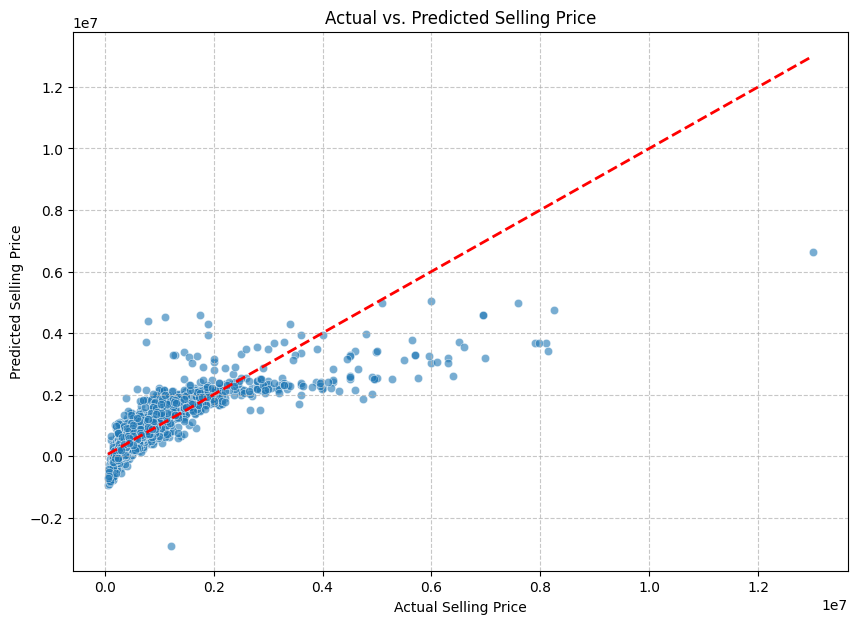

Observation: Points clustered around the red dashed line indicate good predictions. Deviations from the line show prediction errors. We can see some spread, especially at higher selling prices.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot: Actual Selling Price vs Predicted Selling Price
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_np, y=y_pred, alpha=0.6)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', lw=2) # Reference line (perfect prediction)
plt.title('Actual vs. Predicted Selling Price')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Observation: Points clustered around the red dashed line indicate good predictions. Deviations from the line show prediction errors. We can see some spread, especially at higher selling prices.")

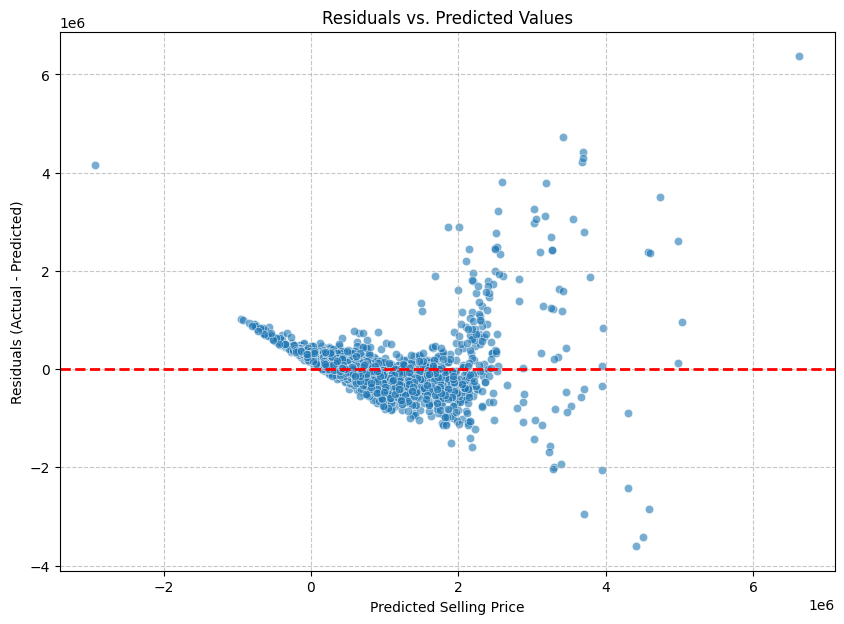

Observation: Ideally, residuals should be randomly scattered around zero with no discernible pattern. Here, we observe some heteroscedasticity (the spread of residuals increases with predicted values), suggesting the model's predictive power might vary across the range of selling prices.


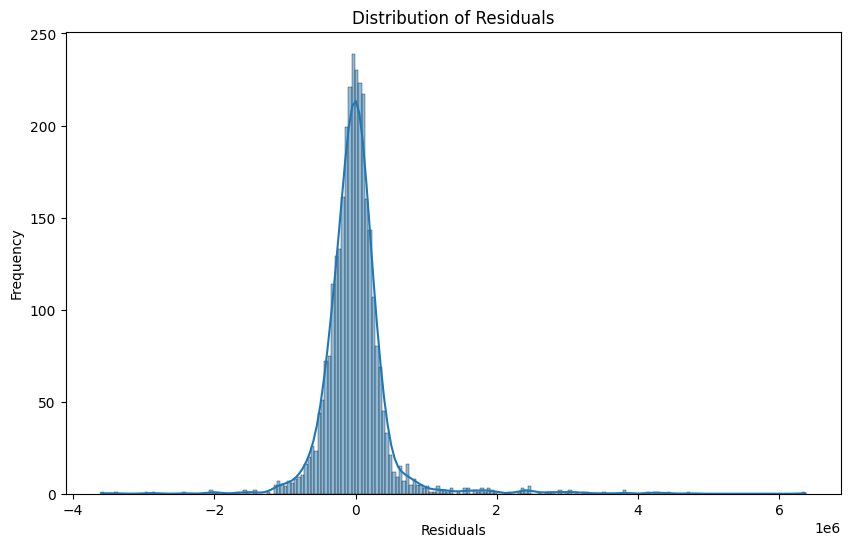

Observation: The histogram shows that the residuals are somewhat centered around zero, but they exhibit a right-skewed distribution, deviating from a normal distribution. This also suggests potential issues with the linearity assumption or that some high-value predictions have larger positive errors.


In [32]:
# Plot or examine the residuals
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Reference line for zero residual
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Selling Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Observation: Ideally, residuals should be randomly scattered around zero with no discernible pattern. Here, we observe some heteroscedasticity (the spread of residuals increases with predicted values), suggesting the model's predictive power might vary across the range of selling prices.")

# Check distribution of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

print("Observation: The histogram shows that the residuals are somewhat centered around zero, but they exhibit a right-skewed distribution, deviating from a normal distribution. This also suggests potential issues with the linearity assumption or that some high-value predictions have larger positive errors.")

In [33]:
# Identify observations with relatively large prediction errors
# Define a threshold for large errors, e.g., residuals exceeding 2 standard deviations
residual_std = np.std(residuals)
threshold = 2 * residual_std

large_errors_indices = np.where(np.abs(residuals) > threshold)[0]

if len(large_errors_indices) > 0:
    print(f"Number of observations with residuals larger than {threshold:.2f} (2 * std dev): {len(large_errors_indices)}")
    print("\nSample of observations with large prediction errors:")
    # Display actual, predicted, and residual for these observations
    large_error_comparison = comparison_df.iloc[large_errors_indices].copy()
    large_error_comparison['Residuals'] = residuals[large_errors_indices]
    display(large_error_comparison.head())
else:
    print("No observations found with residuals larger than 2 standard deviations.")

print("\nPossible reasons for prediction errors:")
print("1. **Non-linearity**: The relationship between features and selling price might not be perfectly linear.")
print("2. **Outliers**: Some extreme data points in the dataset (e.g., very expensive cars, cars with unusual characteristics) can disproportionately influence the model.")
print("3. **Missing Features**: Important features that significantly impact selling price might be missing from our dataset.")
print("4. **Interaction Effects**: There might be complex interactions between features that a simple linear model cannot capture.")
print("5. **Heteroscedasticity**: The variance of errors is not constant across all levels of the predicted outcome, as observed in the residuals plot.")
print("6. **Non-normal Residuals**: The deviation from a normal distribution of residuals indicates that the model assumptions might be violated.")

Number of observations with residuals larger than 1004185.68 (2 * std dev): 104

Sample of observations with large prediction errors:


,Actual Selling Price,Predicted Selling Price,Residuals
20,2850000,1.497573e+06,1.352427e+06
41,4660000,2.829692e+06,1.830308e+06
52,1690000,3.245843e+06,-1.555843e+06
95,1050000,2.056914e+06,-1.006914e+06
117,4200000,2.818862e+06,1.381138e+06



Possible reasons for prediction errors:
1. **Non-linearity**: The relationship between features and selling price might not be perfectly linear.
2. **Outliers**: Some extreme data points in the dataset (e.g., very expensive cars, cars with unusual characteristics) can disproportionately influence the model.
3. **Missing Features**: Important features that significantly impact selling price might be missing from our dataset.
4. **Interaction Effects**: There might be complex interactions between features that a simple linear model cannot capture.
5. **Heteroscedasticity**: The variance of errors is not constant across all levels of the predicted outcome, as observed in the residuals plot.
6. **Non-normal Residuals**: The deviation from a normal distribution of residuals indicates that the model assumptions might be violated.


### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.